# Cell 1 (Markdown)
# 📈 Demand Forecasting — NYC → Dubai

**Business Question:** *"When should a platform push Dubai inventory to NYC users — and how far in advance?"*

### Data Sources
| Source | What It Provides |
|--------|------------------|
| Google Trends (processed) | Monthly demand signal regressors |
| Aviation capacity (processed) | Monthly flights, load factor, passenger proxy |

### Approach
1. Load **processed forecast-ready dataset** (`data/processed/forecast_ready`)
2. Validate schema and quality
3. Analyze supply-demand behavior, seasonality, shocks
4. Benchmark forecasting models
5. Derive search→demand lag and push timing recommendations



In [34]:
import sys, os
from pathlib import Path

sys.path.insert(0, os.path.abspath(".."))
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 4)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from config.settings import DATA_PROCESSED, FIGURES_DIR
from src.analysis.demand_forecaster import run_forecast_benchmarks

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete ✅")

Setup complete ✅


In [35]:
forecast_parquet = DATA_PROCESSED / "forecast_ready.parquet"
forecast_csv = DATA_PROCESSED / "forecast_ready.csv"

analysis_df = None
source_used = None

if forecast_parquet.exists():
    try:
        analysis_df = pd.read_parquet(forecast_parquet)
        source_used = "forecast_ready.parquet"
    except Exception as e:
        print(f"Parquet read failed ({e})")

if analysis_df is None and forecast_csv.exists():
    analysis_df = pd.read_csv(forecast_csv)
    source_used = "forecast_ready.csv"

if analysis_df is None:
    raise FileNotFoundError(
        "No processed forecast file found.\n"
        f"Expected:\n- {forecast_parquet}\n- {forecast_csv}\n\n"
        "Run preprocessing first:\npython scripts/preprocess_all.py --source seeds"
    )

# normalize schema
if "ds" not in analysis_df.columns and "DATE" in analysis_df.columns:
    analysis_df = analysis_df.rename(columns={"DATE": "ds"})
if "y" not in analysis_df.columns and "EST_PASSENGERS" in analysis_df.columns:
    analysis_df = analysis_df.rename(columns={"EST_PASSENGERS": "y"})

analysis_df["ds"] = pd.to_datetime(analysis_df["ds"], errors="coerce")
analysis_df["y"] = pd.to_numeric(analysis_df["y"], errors="coerce")
analysis_df = analysis_df.dropna(subset=["ds", "y"]).sort_values("ds").reset_index(drop=True)

print(f"✅ Loaded processed source: {source_used}")
print(f"Rows: {len(analysis_df)}")
print(f"Date range: {analysis_df['ds'].min().strftime('%Y-%m')} → {analysis_df['ds'].max().strftime('%Y-%m')}")
display(analysis_df.head())

Parquet read failed (Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.)
✅ Loaded processed source: forecast_ready.csv
Rows: 84
Date range: 2019-01 → 2025-12


,ds,y,supply_flights,load_factor,trend_nyc_to_dubai_flights,trend_dubai_hotels,trend_dubai_visa,trend_dubai_tourism,trend_cheap_flights_to_dubai
0,2019-01-01,55654,164,0.893,48.25,65.00,31.00,50.50,37.00
1,2019-02-01,50175,157,0.840,40.75,56.75,29.50,44.75,34.75
2,2019-03-01,40851,139,0.773,32.60,51.60,23.20,37.40,28.20
3,2019-04-01,36979,110,0.880,24.25,42.50,21.25,35.50,25.50
4,2019-05-01,41568,127,0.856,25.50,32.50,16.00,32.25,22.25


In [36]:
merged = analysis_df.copy().rename(columns={"ds": "date", "y": "EST_PASSENGERS"})
merged["date"] = pd.to_datetime(merged["date"], errors="coerce")

if "supply_flights" in merged.columns and "MONTHLY_FLIGHTS" not in merged.columns:
    merged["MONTHLY_FLIGHTS"] = merged["supply_flights"]
if "load_factor" in merged.columns and "LOAD_FACTOR" not in merged.columns:
    merged["LOAD_FACTOR"] = merged["load_factor"]

trend_cols = [c for c in merged.columns if c.startswith("trend_")]

assert len(merged) > 0, "Merged analysis frame is empty"
assert "EST_PASSENGERS" in merged.columns, "Missing EST_PASSENGERS"

print(f"Merged dataset: {merged.shape[0]} months × {merged.shape[1]} columns")
print(f"Trend regressors found: {len(trend_cols)}")
display(merged[["date", "EST_PASSENGERS"] + [c for c in ["MONTHLY_FLIGHTS","LOAD_FACTOR"] if c in merged.columns] + trend_cols[:3]].head())

Merged dataset: 84 months × 11 columns
Trend regressors found: 5


,date,EST_PASSENGERS,MONTHLY_FLIGHTS,LOAD_FACTOR,trend_nyc_to_dubai_flights,trend_dubai_hotels,trend_dubai_visa
0,2019-01-01,55654,164,0.893,48.25,65.00,31.00
1,2019-02-01,50175,157,0.840,40.75,56.75,29.50
2,2019-03-01,40851,139,0.773,32.60,51.60,23.20
3,2019-04-01,36979,110,0.880,24.25,42.50,21.25
4,2019-05-01,41568,127,0.856,25.50,32.50,16.00


## Exploratory Analysis

### Supply & Demand Overview

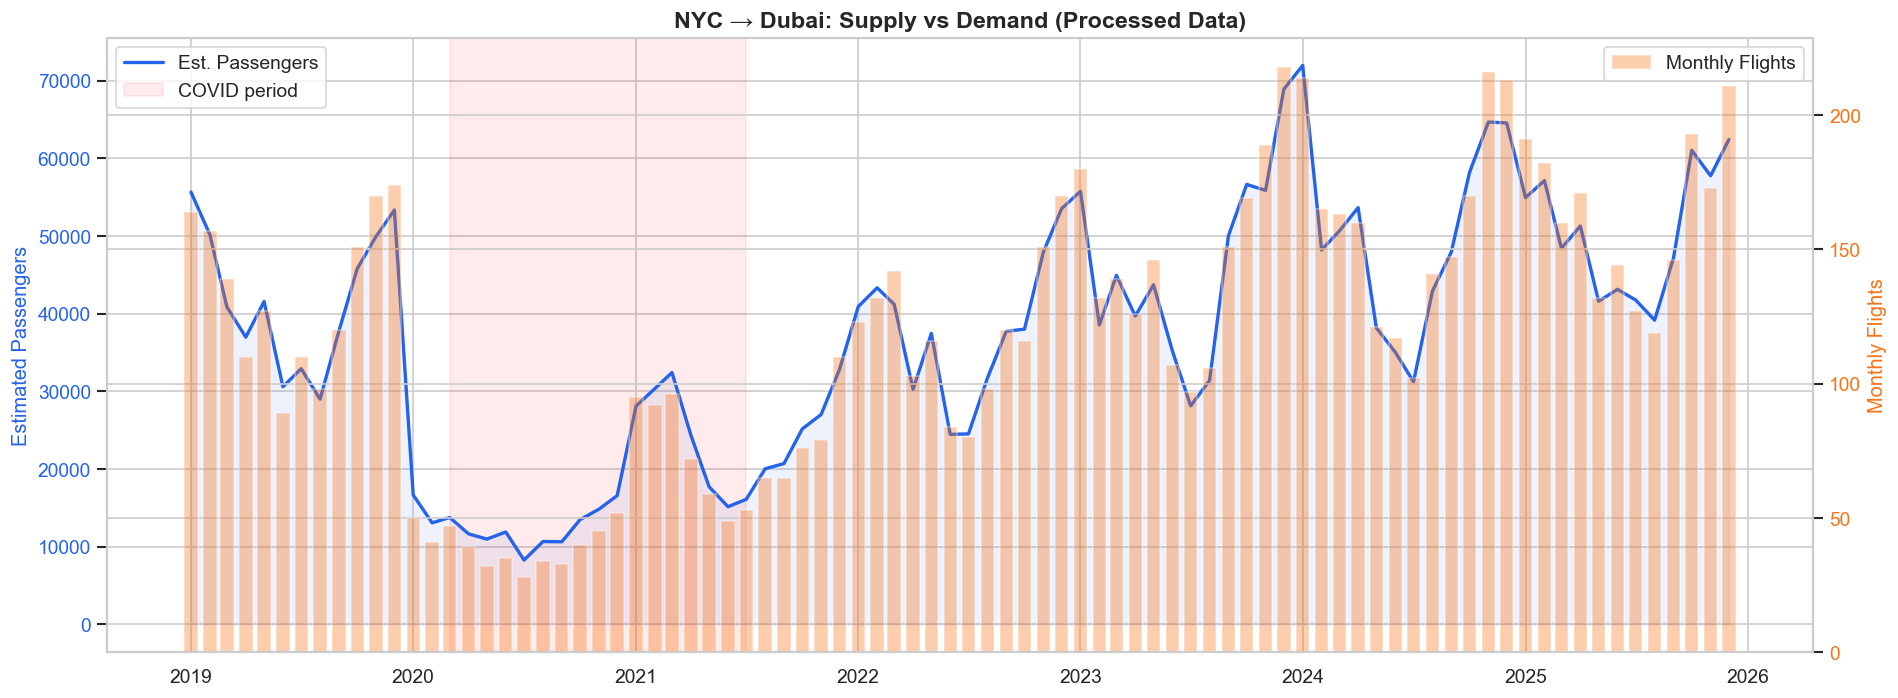

In [37]:
fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.plot(merged["date"], merged["EST_PASSENGERS"], color="#2563eb", linewidth=2, label="Est. Passengers")
ax1.fill_between(merged["date"], merged["EST_PASSENGERS"], alpha=0.08, color="#2563eb")
ax1.set_ylabel("Estimated Passengers", color="#2563eb", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#2563eb")

if "MONTHLY_FLIGHTS" in merged.columns:
    ax2.bar(merged["date"], merged["MONTHLY_FLIGHTS"], width=22, alpha=0.35, color="#f97316", label="Monthly Flights")
    ax2.set_ylabel("Monthly Flights", color="#f97316", fontsize=12)
    ax2.tick_params(axis="y", labelcolor="#f97316")

ax1.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.08, color="red", label="COVID period")
ax1.set_title("NYC → Dubai: Supply vs Demand (Processed Data)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left")
if "MONTHLY_FLIGHTS" in merged.columns:
    ax2.legend(loc="upper right")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_supply_demand_overview.png", dpi=150, bbox_inches="tight")
plt.show()

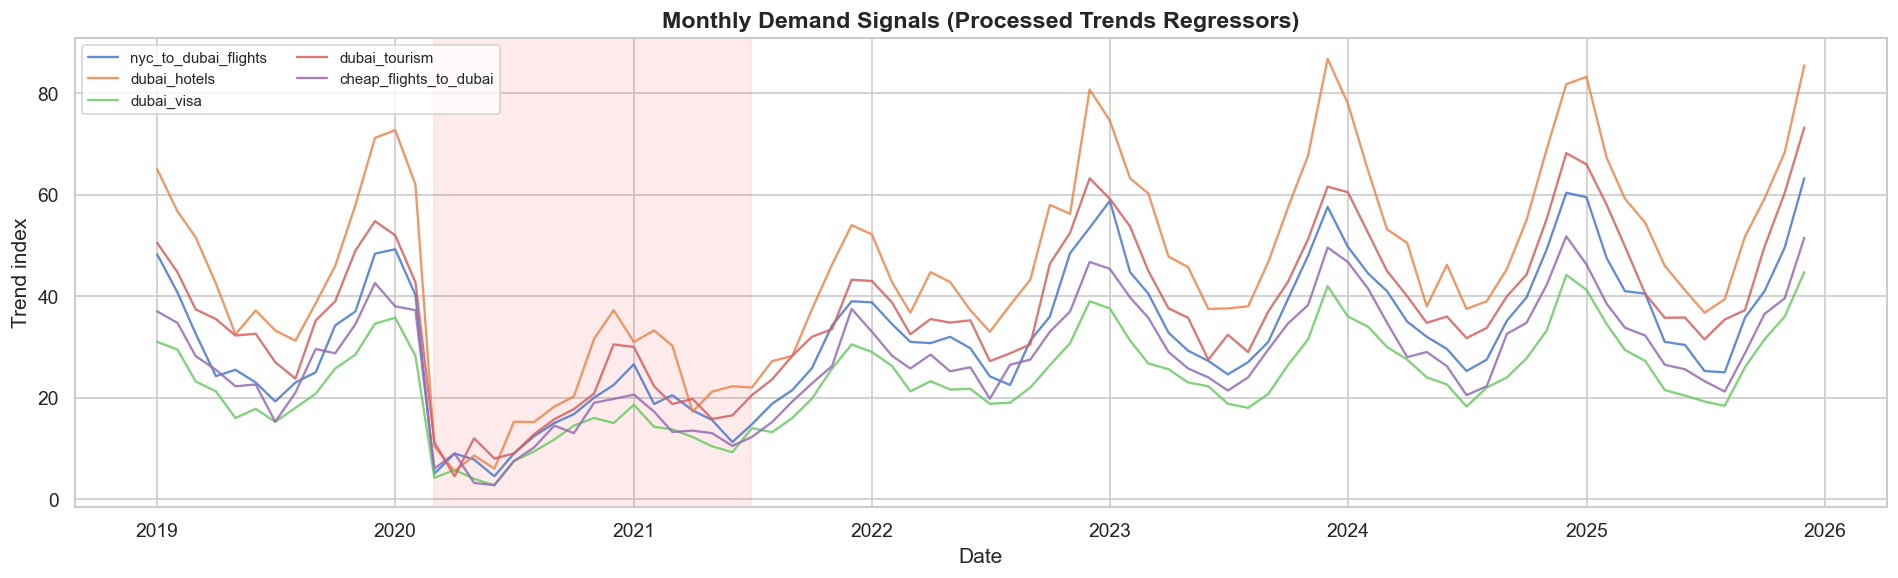

In [38]:
if not trend_cols:
    print("No trend_ columns available in processed frame.")
else:
    fig, ax = plt.subplots(figsize=(16, 5))
    for col in trend_cols:
        ax.plot(merged["date"], merged[col], linewidth=1.4, alpha=0.85, label=col.replace("trend_", ""))

    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.08, color="red")
    ax.set_title("Monthly Demand Signals (Processed Trends Regressors)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Trend index")
    ax.set_xlabel("Date")
    ax.legend(loc="upper left", fontsize=9, ncol=2)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m01_trends_all_keywords.png", dpi=150, bbox_inches="tight")
    plt.show()

### Seasonal Patterns

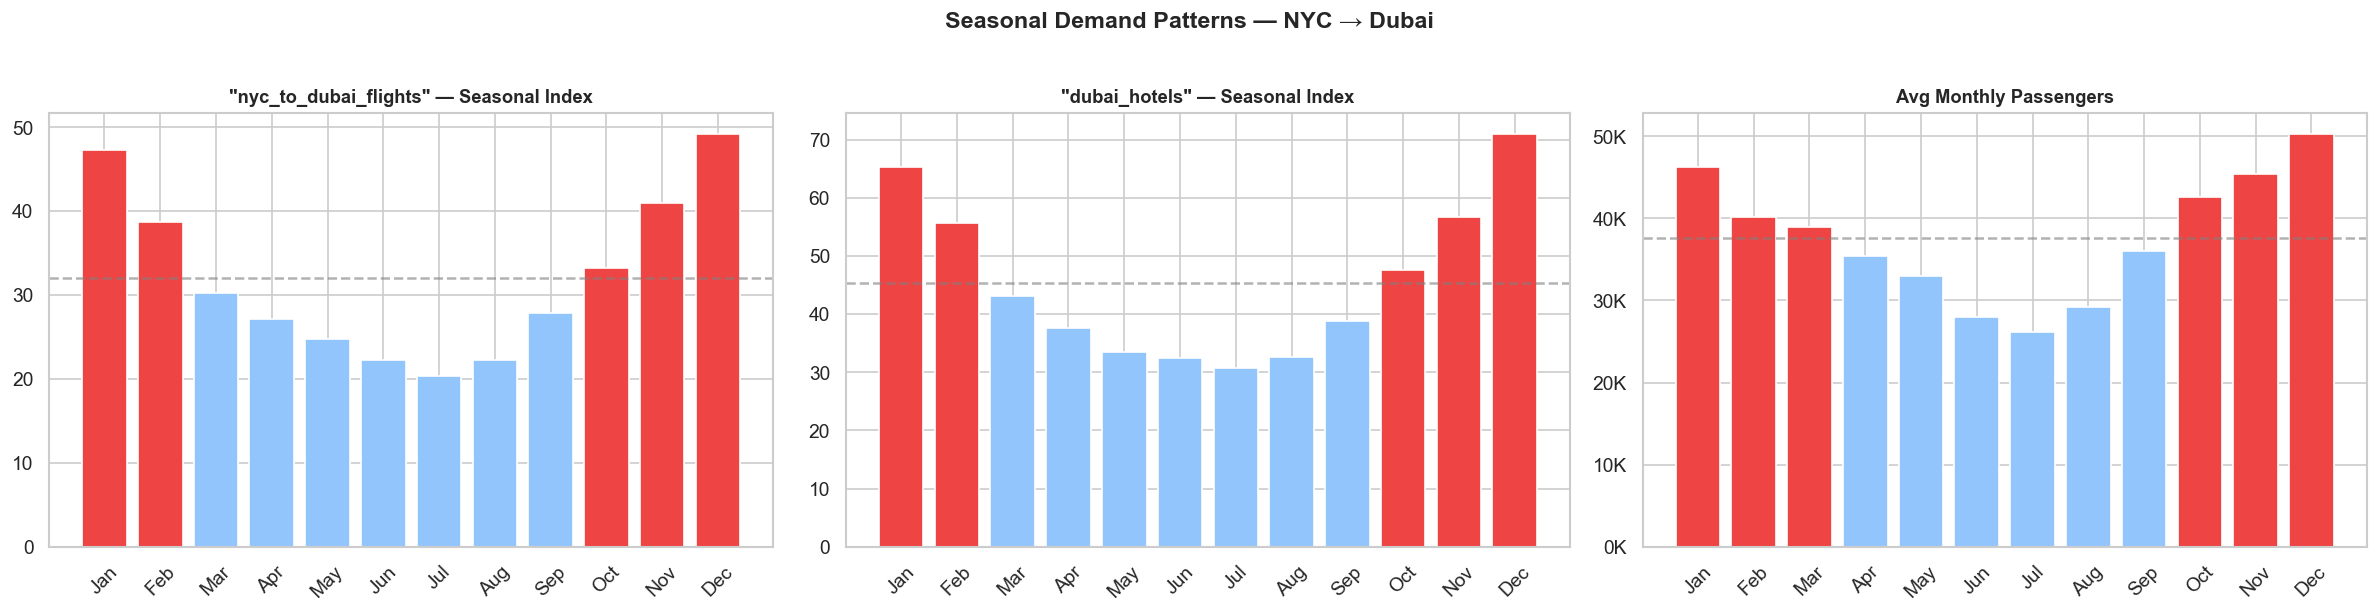

Passenger peak months: Jan, Feb, Mar, Oct, Nov, Dec
Passenger trough months: Apr, May, Jun, Jul, Aug, Sep


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: primary trend seasonality
if trend_cols:
    primary = trend_cols[0]
    s1 = merged.groupby(merged["date"].dt.month)[primary].mean().reindex(range(1,13))
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    colors1 = ["#ef4444" if v > s1.mean() else "#93c5fd" for v in s1.values]
    axes[0].bar(month_names, s1.values, color=colors1, edgecolor="white")
    axes[0].axhline(s1.mean(), color="gray", ls="--", alpha=0.6)
    axes[0].set_title(f'"{primary.replace("trend_","")}" — Seasonal Index', fontsize=11, fontweight="bold")
    axes[0].tick_params(axis="x", rotation=45)
else:
    axes[0].text(0.5, 0.5, "No trend data", ha="center", va="center")
    axes[0].set_title("Trend Seasonality")

# Panel 2: secondary trend
if len(trend_cols) > 1:
    secondary = trend_cols[1]
    s2 = merged.groupby(merged["date"].dt.month)[secondary].mean().reindex(range(1,13))
    colors2 = ["#ef4444" if v > s2.mean() else "#93c5fd" for v in s2.values]
    axes[1].bar(month_names, s2.values, color=colors2, edgecolor="white")
    axes[1].axhline(s2.mean(), color="gray", ls="--", alpha=0.6)
    axes[1].set_title(f'"{secondary.replace("trend_","")}" — Seasonal Index', fontsize=11, fontweight="bold")
    axes[1].tick_params(axis="x", rotation=45)
else:
    axes[1].text(0.5, 0.5, "Need 2+ trend columns", ha="center", va="center")
    axes[1].set_title("Secondary Trend")

# Panel 3: passenger seasonality
m_pax = merged.groupby(merged["date"].dt.month)["EST_PASSENGERS"].mean().reindex(range(1,13))
colors3 = ["#ef4444" if v > m_pax.mean() else "#93c5fd" for v in m_pax.values]
axes[2].bar(month_names, m_pax.values, color=colors3, edgecolor="white")
axes[2].axhline(m_pax.mean(), color="gray", ls="--", alpha=0.6)
axes[2].set_title("Avg Monthly Passengers", fontsize=11, fontweight="bold")
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Seasonal Demand Patterns — NYC → Dubai", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

peak_month_idx = m_pax[m_pax > m_pax.mean()].index.tolist()
trough_month_idx = m_pax[m_pax <= m_pax.mean()].index.tolist()
month_map = {i:m for i,m in enumerate(["","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])}
print("Passenger peak months:", ", ".join(month_map[m] for m in peak_month_idx))
print("Passenger trough months:", ", ".join(month_map[m] for m in trough_month_idx))


### Spike Detection & COVID Impact

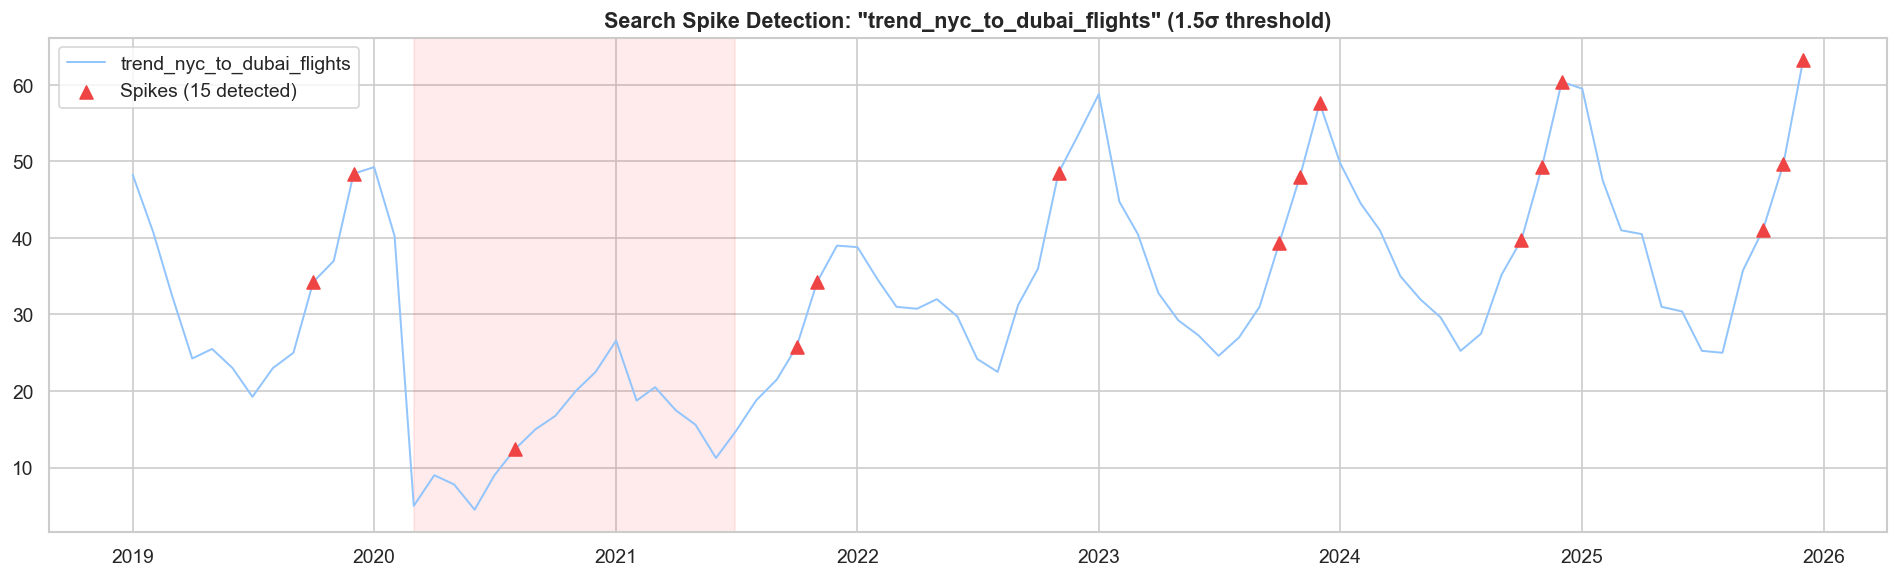


Top 5 spikes by magnitude:
  2023-10: 1.86σ above rolling mean
  2019-10: 1.84σ above rolling mean
  2022-11: 1.75σ above rolling mean
  2023-11: 1.67σ above rolling mean
  2024-11: 1.65σ above rolling mean


In [40]:
def detect_search_spikes_processed(df: pd.DataFrame, col: str, threshold_std: float = 1.5, window: int = 6) -> pd.DataFrame:
    x = df[["date", col]].dropna().copy()
    x = x.set_index("date").sort_index()
    roll_mean = x[col].rolling(window=window, min_periods=3).mean()
    roll_std = x[col].rolling(window=window, min_periods=3).std().replace(0, np.nan)
    z = (x[col] - roll_mean) / roll_std
    spikes = x[z >= threshold_std].copy()
    spikes["SPIKE_MAGNITUDE"] = z[z >= threshold_std]
    return spikes

if trend_cols:
    target_kw = trend_cols[0]
    spikes = detect_search_spikes_processed(merged, target_kw, threshold_std=1.5)

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(merged["date"], merged[target_kw], color="#93c5fd", linewidth=1.2, label=target_kw)
    if not spikes.empty:
        ax.scatter(spikes.index, spikes[target_kw], color="#ef4444", s=60, zorder=5, marker="^",
                   label=f"Spikes ({len(spikes)} detected)")
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.08, color="red")
    ax.set_title(f'Search Spike Detection: "{target_kw}" (1.5σ threshold)', fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m01_spike_detection.png", dpi=150, bbox_inches="tight")
    plt.show()

    if not spikes.empty:
        print("\nTop 5 spikes by magnitude:")
        for dt, row in spikes.nlargest(5, "SPIKE_MAGNITUDE").iterrows():
            print(f"  {dt.strftime('%Y-%m')}: {row['SPIKE_MAGNITUDE']:.2f}σ above rolling mean")
else:
    spikes = pd.DataFrame()
    print("No trend columns available for spike detection.")

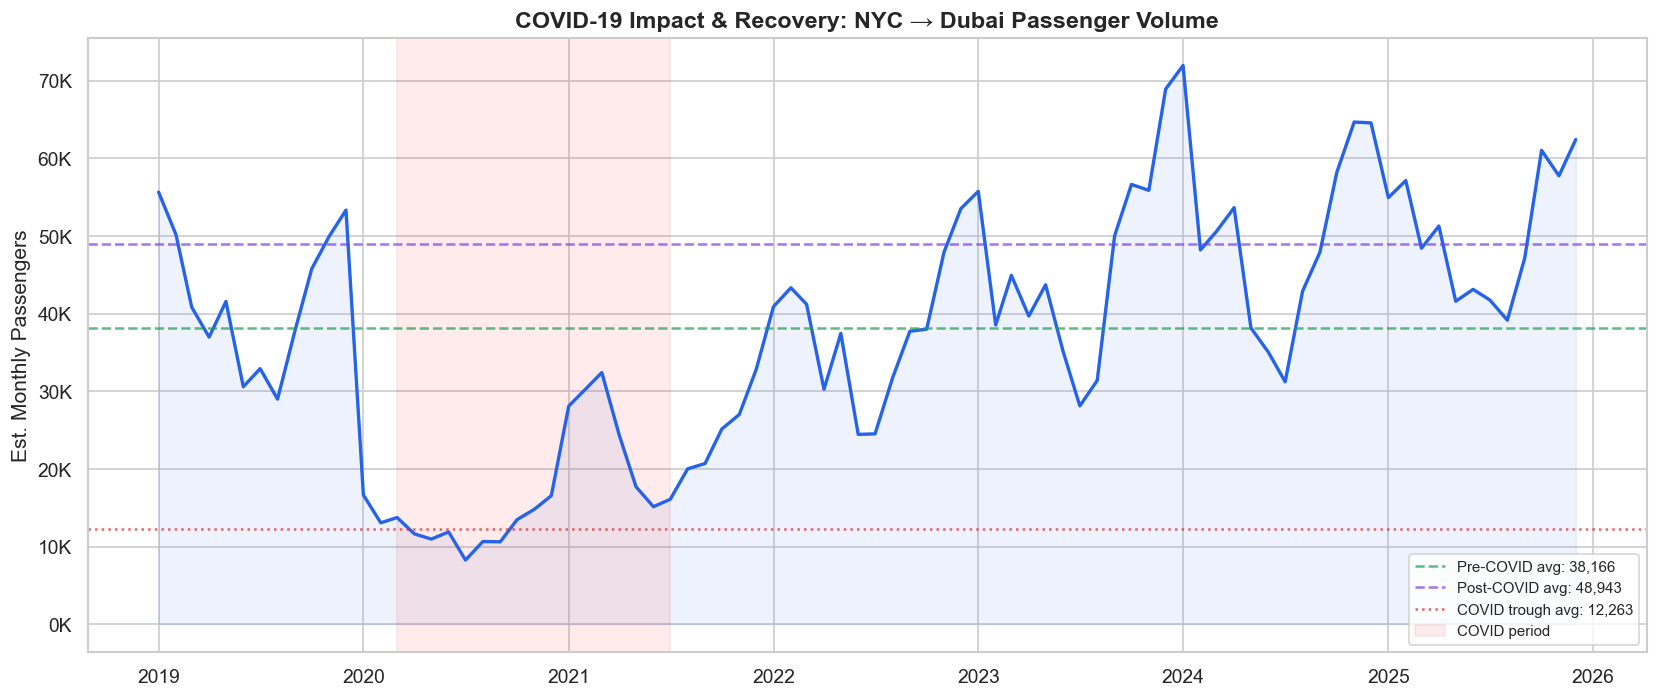

COVID drop: -67.9%
Post-COVID vs pre-COVID: +28.2%


In [41]:
pre_covid = merged[merged["date"] < "2020-03-01"]["EST_PASSENGERS"].mean()
covid_trough = merged[(merged["date"] >= "2020-03-01") & (merged["date"] <= "2020-12-31")]["EST_PASSENGERS"].mean()
post_covid = merged[merged["date"] >= "2023-01-01"]["EST_PASSENGERS"].mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(merged["date"], merged["EST_PASSENGERS"], color="#2563eb", linewidth=2)
ax.fill_between(merged["date"], merged["EST_PASSENGERS"], alpha=0.08, color="#2563eb")
ax.axhline(pre_covid, color="#16a34a", ls="--", alpha=0.7, label=f"Pre-COVID avg: {pre_covid:,.0f}")
ax.axhline(post_covid, color="#7c3aed", ls="--", alpha=0.7, label=f"Post-COVID avg: {post_covid:,.0f}")
ax.axhline(covid_trough, color="#dc2626", ls=":", alpha=0.7, label=f"COVID trough avg: {covid_trough:,.0f}")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.08, color="red", label="COVID period")
ax.set_title("COVID-19 Impact & Recovery: NYC → Dubai Passenger Volume", fontsize=14, fontweight="bold")
ax.set_ylabel("Est. Monthly Passengers")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_covid_impact.png", dpi=150, bbox_inches="tight")
plt.show()

covid_drop_pct = ((covid_trough - pre_covid) / pre_covid * 100)
post_vs_pre_pct = ((post_covid - pre_covid) / pre_covid * 100)
print(f"COVID drop: {covid_drop_pct:.1f}%")
print(f"Post-COVID vs pre-COVID: {post_vs_pre_pct:+.1f}%")

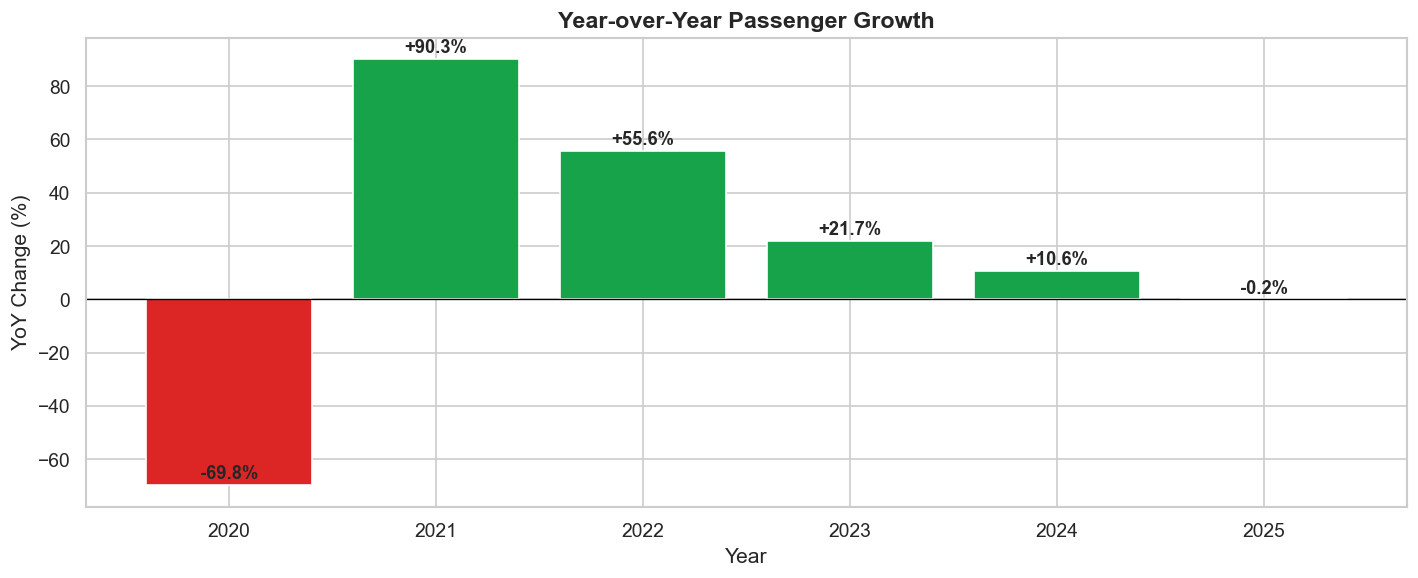

  2020: 152,334 pax (-69.8% vs 2019)
  2021: 289,859 pax (+90.3% vs 2020)
  2022: 451,026 pax (+55.6% vs 2021)
  2023: 548,861 pax (+21.7% vs 2022)
  2024: 607,193 pax (+10.6% vs 2023)
  2025: 605,877 pax (-0.2% vs 2024)


In [42]:
yearly = merged.groupby(merged["date"].dt.year)["EST_PASSENGERS"].sum()
yoy_pct = yearly.pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))
vals = yoy_pct.dropna()
colors = ["#16a34a" if v >= 0 else "#dc2626" for v in vals]
bars = ax.bar(vals.index.astype(str), vals.values, color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, vals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:+.1f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Year-over-Year Passenger Growth", fontsize=14, fontweight="bold")
ax.set_ylabel("YoY Change (%)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_yoy_growth.png", dpi=150, bbox_inches="tight")
plt.show()

for year in sorted(yearly.index):
    if year > yearly.index.min():
        prev, curr = yearly[year-1], yearly[year]
        pct = (curr - prev) / prev * 100
        print(f"  {year}: {curr:,.0f} pax ({pct:+.1f}% vs {year-1})")

## Demand Forecasting — Model Benchmark


In [46]:
bench_df = analysis_df.copy()

bench_df["ds"] = pd.to_datetime(bench_df["ds"], errors="coerce")
bench_df["y"] = pd.to_numeric(bench_df["y"], errors="coerce")
bench_df = bench_df.dropna(subset=["ds", "y"]).sort_values("ds").reset_index(drop=True)

results = run_forecast_benchmarks(bench_df, test_periods=6)

comparison_rows = []
for model_name, r in results.items():
    row = {"MODEL": model_name}
    row.update(r.metrics)
    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)
display(comparison)

best_model = comparison.iloc[0]["MODEL"]
best = results[best_model]

pred = best.predictions.copy()
rename_map = {}
if "DATE" in pred.columns: rename_map["DATE"] = "ds"
if "ACTUAL" in pred.columns: rename_map["ACTUAL"] = "y"
if "PRED" in pred.columns: rename_map["PRED"] = "yhat"
if "RESIDUAL" in pred.columns: rename_map["RESIDUAL"] = "residual"
pred = pred.rename(columns=rename_map)

if "pred" in pred.columns and "yhat" not in pred.columns:
    pred["yhat"] = pred["pred"]

display(pred.head())

,MODEL,MAE,RMSE,MAPE
0,seasonal_naive,4486.8333,5565.3039,9.4014
1,linear_trend,8310.1837,8712.9002,17.0233
2,naive,10204.3333,12525.7082,17.9293


,ds,y,pred,residual,yhat
78,2025-07-01,41755,31229.0,10526.0,31229.0
79,2025-08-01,39164,42889.0,-3725.0,42889.0
80,2025-09-01,47170,47931.0,-761.0,47931.0
81,2025-10-01,61041,58191.0,2850.0,58191.0
82,2025-11-01,57762,64682.0,-6920.0,64682.0


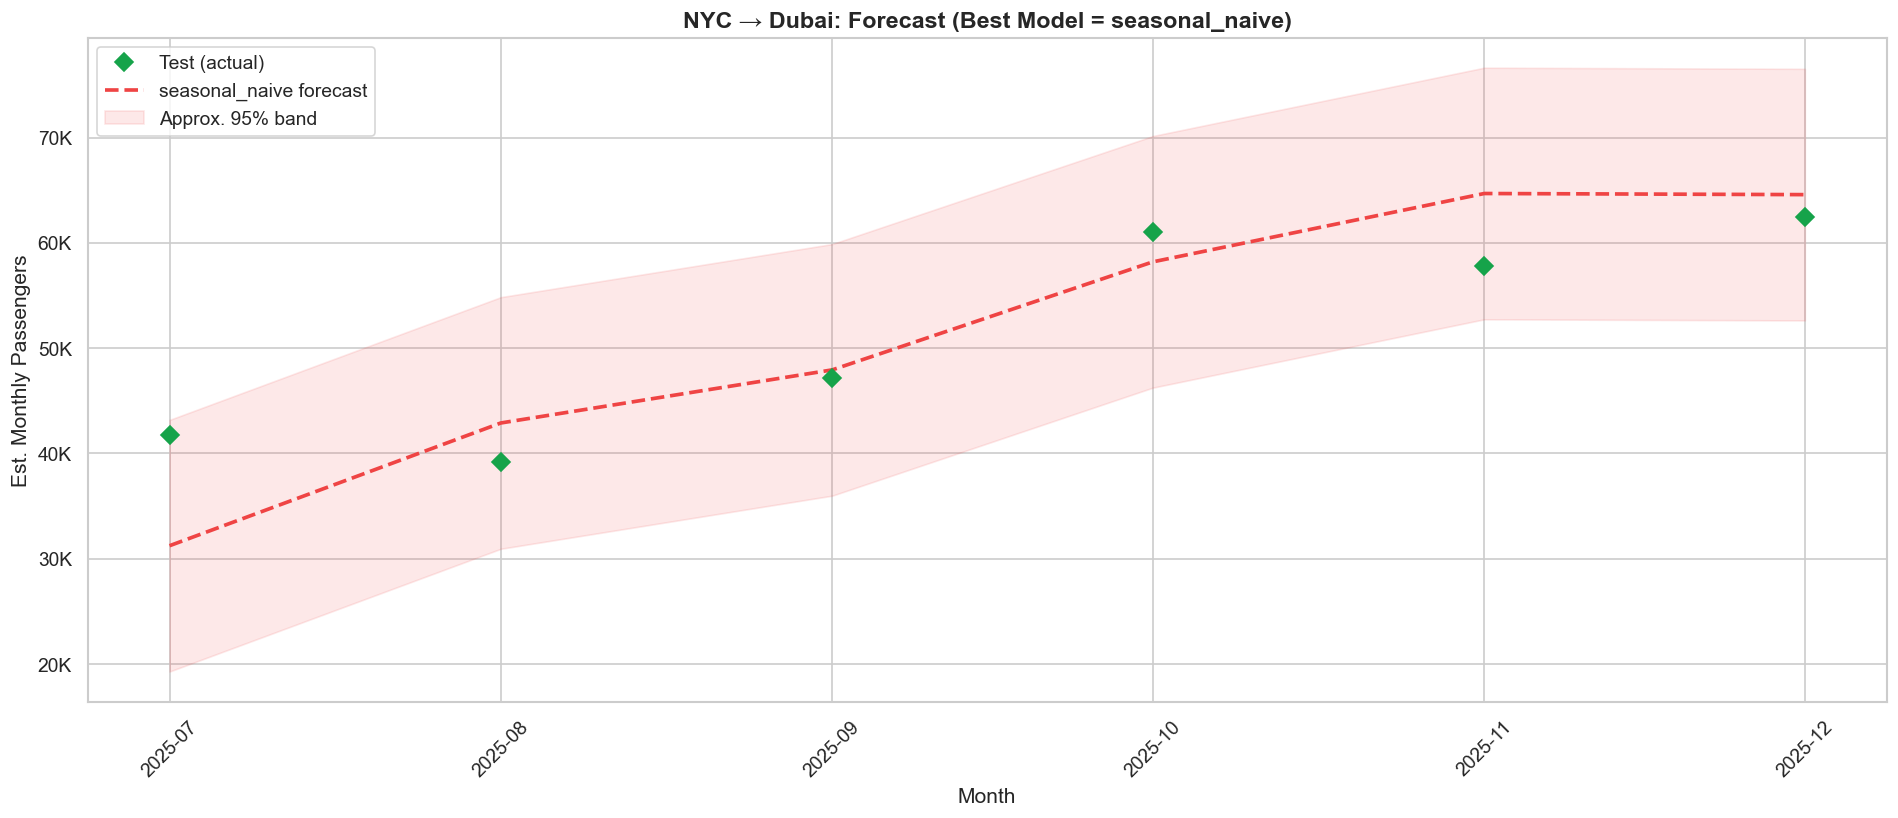

In [47]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(pred["ds"], pred["y"], "D", color="#16a34a", markersize=8, label="Test (actual)", zorder=5)
ax.plot(pred["ds"], pred["yhat"], "--", color="#ef4444", linewidth=2.2, label=f"{best_model} forecast")

# pseudo CI band from residual std (visual uncertainty band)
resid_std = float(pred["residual"].std(ddof=1)) if len(pred) > 1 else 0.0
ax.fill_between(pred["ds"], pred["yhat"] - 1.96*resid_std, pred["yhat"] + 1.96*resid_std,
                alpha=0.12, color="#ef4444", label="Approx. 95% band")

ax.set_title(f"NYC → Dubai: Forecast (Best Model = {best_model})", fontsize=14, fontweight="bold")
ax.set_ylabel("Est. Monthly Passengers")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m01_best_model_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

## Search → Demand Lag Analysis

*If someone searches now, how many months until demand responds?*

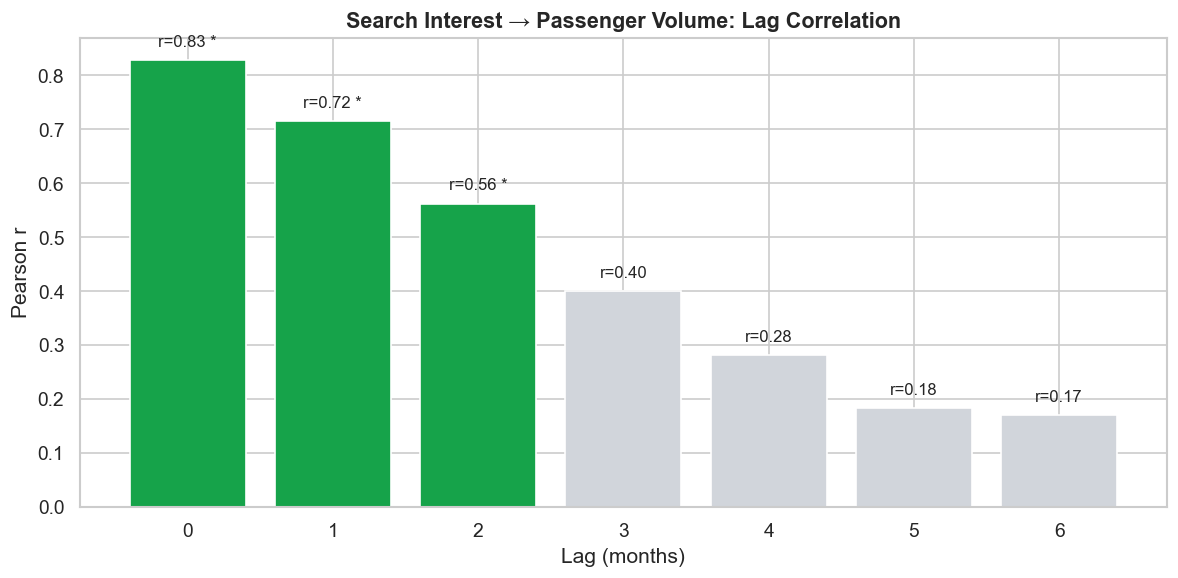

,lag_months,correlation,significant,n
0,0,0.828680,True,84
1,1,0.715095,True,83
2,2,0.562032,True,82
3,3,0.400364,False,81
4,4,0.281090,False,80
5,5,0.183028,False,79
6,6,0.169024,False,78


In [48]:
def analyze_search_demand_lag_processed(df: pd.DataFrame, search_col: str, y_col: str = "EST_PASSENGERS", max_lag: int = 6):
    rows = []
    x = df[["date", search_col, y_col]].dropna().sort_values("date").copy()

    for lag in range(0, max_lag + 1):
        tmp = x.copy()
        tmp["search_lag"] = tmp[search_col].shift(lag)
        tmp = tmp.dropna(subset=["search_lag", y_col])

        if len(tmp) < 6:
            rows.append({"lag_months": lag, "correlation": np.nan, "significant": False, "n": len(tmp)})
            continue

        r = np.corrcoef(tmp["search_lag"], tmp[y_col])[0, 1]
        significant = abs(r) >= 0.5  # practical threshold
        rows.append({"lag_months": lag, "correlation": float(r), "significant": bool(significant), "n": len(tmp)})

    return pd.DataFrame(rows)

if trend_cols:
    lag_results = analyze_search_demand_lag_processed(merged, search_col=trend_cols[0], y_col="EST_PASSENGERS", max_lag=6)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#16a34a" if s else "#d1d5db" for s in lag_results["significant"]]
    bars = ax.bar(lag_results["lag_months"], lag_results["correlation"], color=colors, edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.5)

    for bar, row in zip(bars, lag_results.itertuples()):
        if pd.isna(row.correlation):
            continue
        label = f"r={row.correlation:.2f}" + (" *" if row.significant else "")
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, label,
                ha="center", va="bottom", fontsize=10)

    ax.set_title("Search Interest → Passenger Volume: Lag Correlation", fontsize=13, fontweight="bold")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Pearson r")
    ax.set_xticks(lag_results["lag_months"])

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m01_lag_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

    display(lag_results)
else:
    lag_results = pd.DataFrame()
    print("No trend regressors available for lag analysis.")

In [50]:
def generate_push_timing_processed(pred_df: pd.DataFrame, lead_months: int = 3):
    x = pred_df.copy().dropna(subset=["ds", "yhat"])
    x["PEAK_FLAG"] = x["yhat"] >= x["yhat"].quantile(0.75)
    peaks = x[x["PEAK_FLAG"]].copy()

    if peaks.empty:
        return pd.DataFrame()

    out = peaks[["ds", "yhat"]].rename(columns={"ds":"PEAK_MONTH", "yhat":"FORECAST_PAX"})
    out["PUSH_START"] = (pd.to_datetime(out["PEAK_MONTH"]) - pd.DateOffset(months=lead_months)).dt.strftime("%Y-%m")
    out["PUSH_END"] = (pd.to_datetime(out["PEAK_MONTH"]) - pd.DateOffset(months=1)).dt.strftime("%Y-%m")
    out["SEASON"] = pd.to_datetime(out["PEAK_MONTH"]).dt.month.map(
        lambda m: "Peak Winter" if m in [11, 12, 1, 2] else ("Summer Low" if m in [6,7,8] else "Transition")
    )
    out["RECOMMENDATION"] = out.apply(
        lambda r: f"Start push in {r['PUSH_START']} and sustain until {r['PUSH_END']} for peak month {pd.to_datetime(r['PEAK_MONTH']).strftime('%Y-%m')}",
        axis=1
    )
    return out.sort_values("FORECAST_PAX", ascending=False).reset_index(drop=True)

recs = generate_push_timing_processed(pred, lead_months=3)

if not recs.empty:
    print("Push Timing Recommendations:\n")
    for _, r in recs.iterrows():
        print(f"  {r['RECOMMENDATION']}")
    print()
    display(recs[["PEAK_MONTH", "FORECAST_PAX", "PUSH_START", "PUSH_END", "SEASON"]])
else:
    print("No peak months in forecast horizon")

Push Timing Recommendations:

  Start push in 2025-08 and sustain until 2025-10 for peak month 2025-11
  Start push in 2025-09 and sustain until 2025-11 for peak month 2025-12



,PEAK_MONTH,FORECAST_PAX,PUSH_START,PUSH_END,SEASON
0,2025-11-01,64682.0,2025-08,2025-10,Peak Winter
1,2025-12-01,64575.0,2025-09,2025-11,Peak Winter


In [ ]:

out = DATA_PROCESSED / "demand_forecasting"
out.mkdir(parents=True, exist_ok=True)

merged.to_csv(out / "merged_supply_demand_processed.csv", index=False)
comparison.to_csv(out / "model_comparison.csv", index=False)
pred.to_csv(out / "best_model_forecast_holdout.csv", index=False)
lag_results.to_csv(out / "lag_analysis.csv", index=False)
if not recs.empty:
    recs.to_csv(out / "push_timing_recommendations.csv", index=False)

print(f"Outputs saved to: {out}")
print(f"Figures saved to: {FIGURES_DIR}")

Outputs saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\demand_forecasting
Figures saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures
